# Citizen Sensor Tracker — Exploratory Data Analysis

**Question:** Do spikes in citizen 311 complaints (air pollution work orders) correlate with actual spikes in localized air pollution as measured by Open Air Chicago sensors?

**Data sources:**
- **CDPH Environmental Complaints** (`fypr-ksnz`) — air pollution work orders, Sep 2025 – Feb 2026
- **Open Air Chicago Day Aggregations** (`rtmx-vkjr`) — daily PM2.5 means from 286 sensors

**Methodology:** Each complaint is spatially assigned to the nearest sensor via Haversine distance. We then compare daily complaint counts with daily PM2.5 readings at both the sensor and citywide level.

In [1]:
# ── Setup & Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from pathlib import Path
import sqlite3
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path("..").resolve()
CLEAN_DIR = PROJECT_ROOT / "data" / "clean"
DB_PATH = PROJECT_ROOT / "db" / "citizen_sensor.db"

# Load datasets
merged = pd.read_csv(CLEAN_DIR / "merged_complaints_air.csv", parse_dates=["date"])
complaints = pd.read_csv(CLEAN_DIR / "complaints_cleaned.csv", parse_dates=["complaint_date"])
air = pd.read_csv(CLEAN_DIR / "openair_daily_cleaned.csv", parse_dates=["date"])

print(f"Merged:     {len(merged):>8,} rows  |  {merged['sensor_name'].nunique()} sensors")
print(f"Complaints: {len(complaints):>8,} rows  |  Date range: {complaints['complaint_date'].min().date()} → {complaints['complaint_date'].max().date()}")
print(f"Air data:   {len(air):>8,} rows  |  Date range: {air['date'].min().date()} → {air['date'].max().date()}")

Merged:       47,967 rows  |  286 sensors
Complaints:      585 rows  |  Date range: 2025-09-01 → 2026-02-26
Air data:     47,967 rows  |  Date range: 2025-08-31 → 2026-02-19


## Section 1 — Univariate Distributions

Before correlating the two datasets, let's understand each one individually: how is PM2.5 distributed across sensor-days? How many complaints arrive per day?

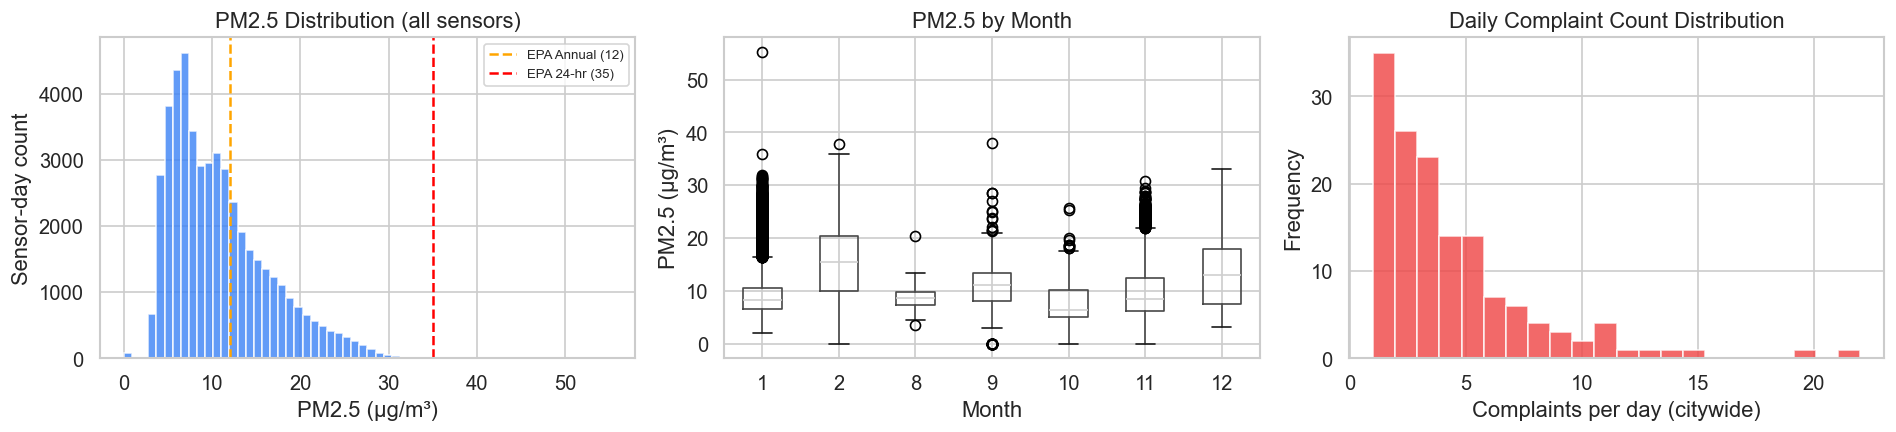

── PM2.5 Summary ──
count    47967.00
mean        10.82
std          5.55
min          0.00
25%          6.50
50%          9.62
75%         13.88
max         55.21
Name: pm25_mean, dtype: float64

Days above EPA 24-hr (35 µg/m³): 5

── Complaints Summary ──
Total complaints: 585
Date range:       2025-09-01 → 2026-02-26
Daily mean:       4.1
Daily max:        22


In [2]:
# ── 1a. PM2.5 Distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(air["pm25_mean"].dropna(), bins=60, edgecolor="white", alpha=0.8, color="#3b82f6")
axes[0].axvline(12, color="orange", ls="--", lw=1.5, label="EPA Annual (12)")
axes[0].axvline(35, color="red",    ls="--", lw=1.5, label="EPA 24-hr (35)")
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].set_ylabel("Sensor-day count")
axes[0].set_title("PM2.5 Distribution (all sensors)")
axes[0].legend(fontsize=8)

# Box plot by month
air["month"] = air["date"].dt.month
air.boxplot(column="pm25_mean", by="month", ax=axes[1])
axes[1].set_title("PM2.5 by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("PM2.5 (µg/m³)")
plt.suptitle("")  # remove auto-title

# Daily complaint counts (citywide)
daily_complaints = complaints.groupby(complaints["complaint_date"].dt.date).size()
axes[2].hist(daily_complaints.values, bins=max(daily_complaints.max(), 15),
             edgecolor="white", alpha=0.8, color="#ef4444")
axes[2].set_xlabel("Complaints per day (citywide)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Daily Complaint Count Distribution")

plt.tight_layout()
plt.show()

# Summary stats
print("── PM2.5 Summary ──")
print(air["pm25_mean"].describe().round(2))
print(f"\nDays above EPA 24-hr (35 µg/m³): {(air['pm25_mean'] > 35).sum()}")
print(f"\n── Complaints Summary ──")
print(f"Total complaints: {len(complaints)}")
print(f"Date range:       {complaints['complaint_date'].min().date()} → {complaints['complaint_date'].max().date()}")
print(f"Daily mean:       {daily_complaints.mean():.1f}")
print(f"Daily max:        {daily_complaints.max()}")

## Section 2 — Temporal Patterns

The core question: when PM2.5 spikes, do complaints follow? We overlay citywide daily complaint counts and mean PM2.5 on a dual-axis time series, then look at day-of-week patterns.

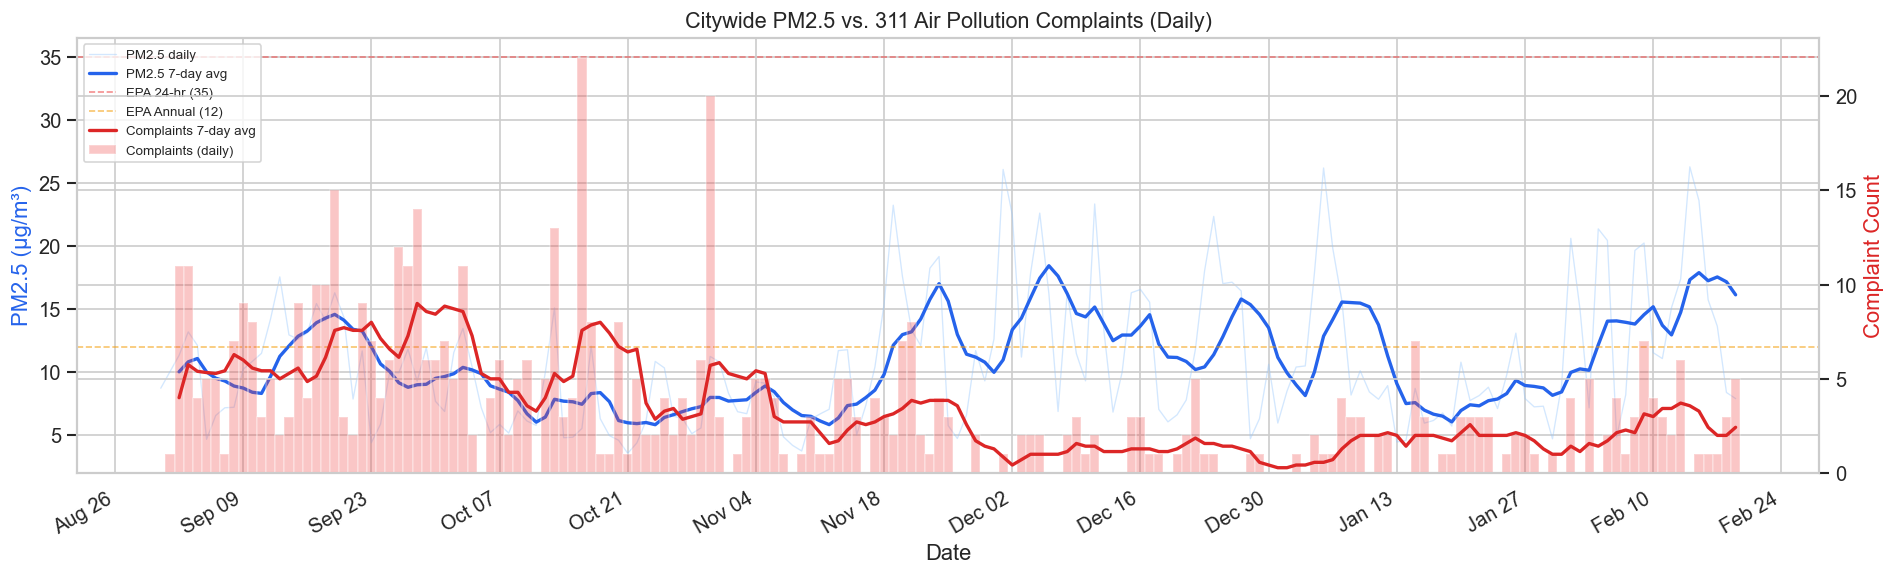

In [3]:
# ── 2a. Dual-Axis Time Series: Citywide PM2.5 vs. Complaint Count ────────────
# Aggregate to citywide daily
city_air = air.groupby("date").agg(pm25_city_mean=("pm25_mean", "mean")).reset_index()
city_comp = (
    complaints.groupby(complaints["complaint_date"].dt.normalize())
    .size()
    .reset_index(name="complaint_count")
    .rename(columns={"complaint_date": "date"})
)
city_comp["date"] = pd.to_datetime(city_comp["date"])

# Merge on date
city = city_air.merge(city_comp, on="date", how="left")
city["complaint_count"] = city["complaint_count"].fillna(0).astype(int)

# 7-day rolling averages
city["pm25_7d"] = city["pm25_city_mean"].rolling(7, min_periods=3).mean()
city["comp_7d"] = city["complaint_count"].rolling(7, min_periods=3).mean()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

# PM2.5
ax1.plot(city["date"], city["pm25_city_mean"], color="#93c5fd", alpha=0.4, lw=0.8, label="PM2.5 daily")
ax1.plot(city["date"], city["pm25_7d"], color="#2563eb", lw=2, label="PM2.5 7-day avg")
ax1.axhline(35, color="#ef4444", ls="--", lw=1, alpha=0.6, label="EPA 24-hr (35)")
ax1.axhline(12, color="#f59e0b", ls="--", lw=1, alpha=0.6, label="EPA Annual (12)")
ax1.set_ylabel("PM2.5 (µg/m³)", color="#2563eb")
ax1.set_xlabel("Date")

# Complaints
ax2.bar(city["date"], city["complaint_count"], alpha=0.3, color="#ef4444", width=1, label="Complaints (daily)")
ax2.plot(city["date"], city["comp_7d"], color="#dc2626", lw=2, label="Complaints 7-day avg")
ax2.set_ylabel("Complaint Count", color="#dc2626")

# Format
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
fig.autofmt_xdate()

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

ax1.set_title("Citywide PM2.5 vs. 311 Air Pollution Complaints (Daily)", fontsize=13)
plt.tight_layout()
plt.show()

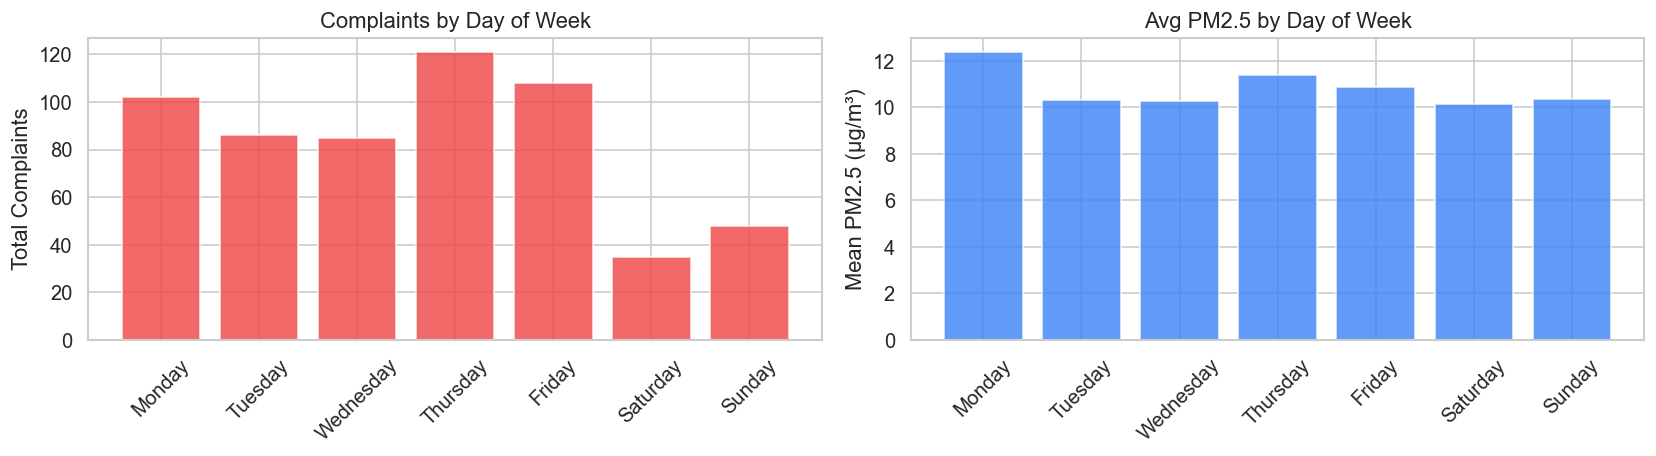

Key insight: Are complaints concentrated on weekdays
(when offices process 311 calls) regardless of air quality?


In [4]:
# ── 2b. Day-of-Week Heatmap ──────────────────────────────────────────────────
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Complaints per day of week
comp_dow = complaints.copy()
comp_dow["dow"] = comp_dow["complaint_date"].dt.day_name()
dow_counts = comp_dow.groupby("dow").size().reindex(dow_order)

# Mean PM2.5 per day of week
air_dow = air.copy()
air_dow["dow"] = air_dow["date"].dt.day_name()
dow_pm25 = air_dow.groupby("dow")["pm25_mean"].mean().reindex(dow_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(dow_order, dow_counts.values, color="#ef4444", alpha=0.8, edgecolor="white")
ax1.set_ylabel("Total Complaints")
ax1.set_title("Complaints by Day of Week")
ax1.tick_params(axis="x", rotation=45)

ax2.bar(dow_order, dow_pm25.values, color="#3b82f6", alpha=0.8, edgecolor="white")
ax2.set_ylabel("Mean PM2.5 (µg/m³)")
ax2.set_title("Avg PM2.5 by Day of Week")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Key insight: Are complaints concentrated on weekdays")
print("(when offices process 311 calls) regardless of air quality?")

## Section 3 — Spatial Patterns

Which sensor areas attract the most complaints? Is there a relationship between a sensor's average PM2.5 readings and the number of complaints near that sensor?

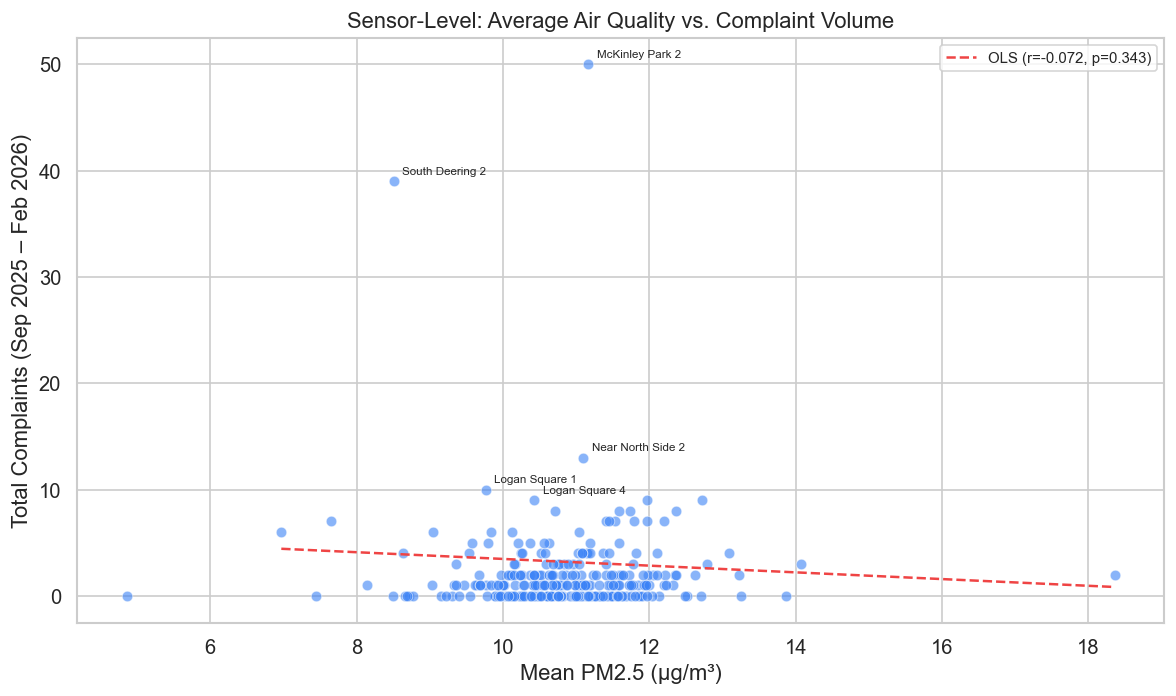


Sensors with data: 286
Sensors with ≥1 complaint nearby: 176


In [5]:
# ── 3a. Scatter: Mean PM2.5 by Sensor vs. Total Complaints Near That Sensor ─
sensor_stats = merged.groupby("sensor_name").agg(
    avg_pm25=("pm25_mean", "mean"),
    total_complaints=("complaint_count", "sum"),
    lat=("lat", "first"),
    lon=("lon", "first"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

# Size by total sensor-days (more data → bigger dot)
scatter = ax.scatter(
    sensor_stats["avg_pm25"],
    sensor_stats["total_complaints"],
    alpha=0.6,
    s=40,
    c="#3b82f6",
    edgecolors="white",
    linewidths=0.5,
)

# Annotate sensors with highest complaints
top = sensor_stats.nlargest(5, "total_complaints")
for _, row in top.iterrows():
    ax.annotate(
        row["sensor_name"],
        (row["avg_pm25"], row["total_complaints"]),
        fontsize=7, ha="left", va="bottom",
        xytext=(5, 3), textcoords="offset points",
    )

# Regression line
mask = sensor_stats["total_complaints"] > 0
if mask.sum() > 2:
    x = sensor_stats.loc[mask, "avg_pm25"]
    y = sensor_stats.loc[mask, "total_complaints"]
    slope, intercept, r, p, se = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, slope * xline + intercept, color="#ef4444", ls="--", lw=1.5,
            label=f"OLS (r={r:.3f}, p={p:.3f})")
    ax.legend(fontsize=9)

ax.set_xlabel("Mean PM2.5 (µg/m³)")
ax.set_ylabel("Total Complaints (Sep 2025 – Feb 2026)")
ax.set_title("Sensor-Level: Average Air Quality vs. Complaint Volume")
plt.tight_layout()
plt.show()

print(f"\nSensors with data: {len(sensor_stats)}")
print(f"Sensors with ≥1 complaint nearby: {(sensor_stats['total_complaints'] > 0).sum()}")

## Section 4 — Neighborhood-Level Analysis

In [6]:
# ── 4a. Neighborhood Map: Mean PM2.5 ───────────────────────────────────────
import geopandas as gpd

NEIGHBORHOODS_GEOJSON = CLEAN_DIR / "chicago_neighborhoods.geojson"
neighborhood_summary = pd.read_csv(CLEAN_DIR / "neighborhood_summary.csv")

gdf = gpd.read_file(NEIGHBORHOODS_GEOJSON)

# Merge GeoDataFrame with neighborhood summary data
merged_gdf = gdf.merge(neighborhood_summary, left_on="pri_neigh", right_on="neighborhood", how="left")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
merged_gdf.plot(column='pm25_mean', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mean PM2.5 by Neighborhood')
ax.set_axis_off()
plt.show()

# ── 4b. Bar Chart: Complaints by Neighborhood ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
neighborhood_summary.sort_values("total_complaints", ascending=False, inplace=True)
sns.barplot(x="total_complaints", y="neighborhood", data=neighborhood_summary.head(20), ax=ax)
ax.set_xlabel("Total Complaints")
ax.set_ylabel("Neighborhood")
ax.set_title("Top 20 Neighborhoods by Complaint Volume")
plt.tight_layout()
plt.show()

KeyError: 'pri_neigh'

## Section 5 — Deeper Dive into 311 Complaints

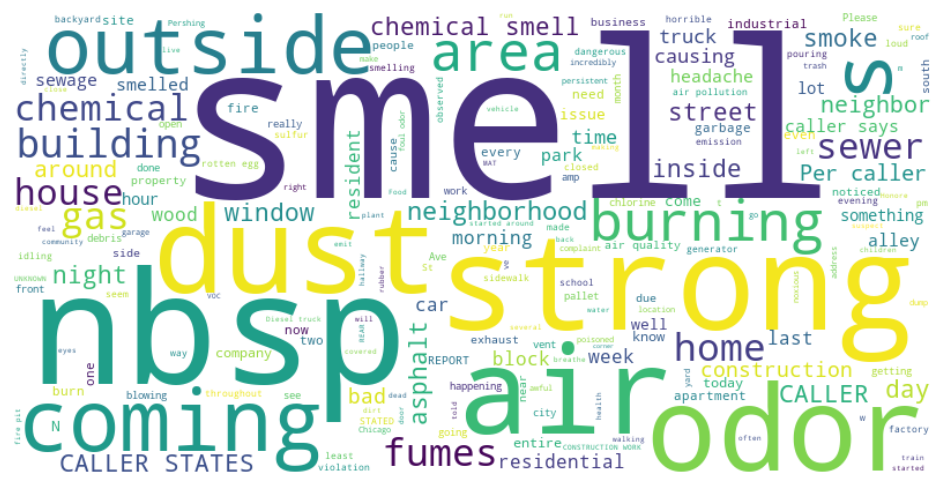

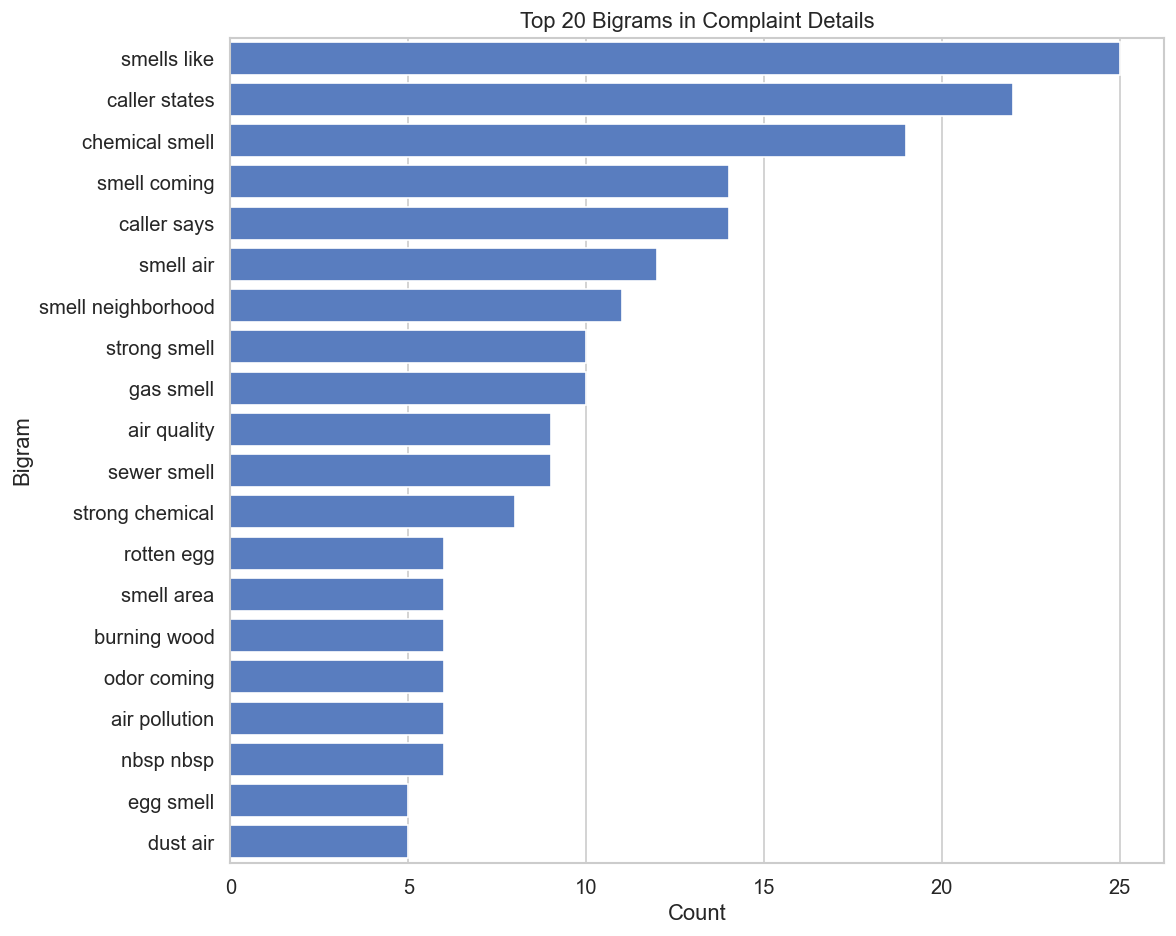

In [7]:
# ── 5a. Word Cloud of Complaint Details ───────────────────────────────────
from wordcloud import WordCloud

text = ' '.join(complaints['complaint_detail'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# ── 5b. Bar Chart of Most Frequent N-grams ─────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=None, ngram_range=(1, 1)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

top_bigrams = get_top_ngrams(complaints['complaint_detail'].dropna(), n=20, ngram_range=(2, 2))

df_bigrams = pd.DataFrame(top_bigrams, columns=['bigram', 'count'])

plt.figure(figsize=(10, 8))
sns.barplot(x='count', y='bigram', data=df_bigrams)
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.title('Top 20 Bigrams in Complaint Details')
plt.tight_layout()
plt.show()

## Section 6 — Lead/Lag Analysis (Cross-Correlation)

The most interesting question: does bad air quality *precede* complaints (citizens react to poor air), or do complaints come *first* (anticipatory/odor-based)? We compute the cross-correlation function (CCF) between PM2.5 and complaint count at lags of -7 to +7 days.

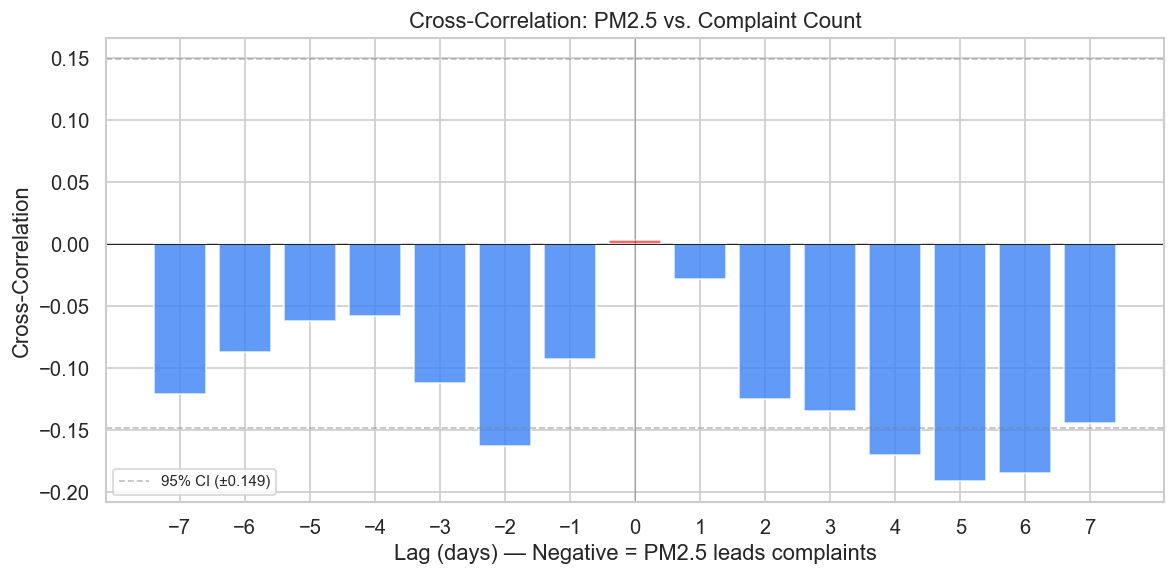

Peak |CCF| = 0.192 at lag = 5 days
→ Complaints lead PM2.5 (complaints precede measured spikes)


In [8]:
# ── 4a. Cross-Correlation Function (CCF) ─────────────────────────────────────
# Work with citywide daily series (same 'city' dataframe from Section 2)
pm25_series = city["pm25_city_mean"].dropna().values
comp_series = city["complaint_count"].dropna().values

# Ensure same length
n = min(len(pm25_series), len(comp_series))
pm25_series = pm25_series[:n]
comp_series = comp_series[:n]

# Standardize
pm25_z = (pm25_series - pm25_series.mean()) / pm25_series.std()
comp_z = (comp_series - comp_series.mean()) / max(comp_series.std(), 1e-10)

# Compute CCF at lags -7 to +7
max_lag = 7
lags = range(-max_lag, max_lag + 1)
ccf_values = []
for lag in lags:
    if lag < 0:
        corr = np.corrcoef(pm25_z[:lag], comp_z[-lag:])[0, 1]
    elif lag > 0:
        corr = np.corrcoef(pm25_z[lag:], comp_z[:-lag])[0, 1]
    else:
        corr = np.corrcoef(pm25_z, comp_z)[0, 1]
    ccf_values.append(corr)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#ef4444" if v > 0 else "#3b82f6" for v in ccf_values]
ax.bar(lags, ccf_values, color=colors, alpha=0.8, edgecolor="white")

# 95% confidence interval
ci = 1.96 / np.sqrt(n)
ax.axhline(ci,  color="gray", ls="--", lw=1, alpha=0.5, label=f"95% CI (±{ci:.3f})")
ax.axhline(-ci, color="gray", ls="--", lw=1, alpha=0.5)
ax.axhline(0,   color="black", lw=0.5)
ax.axvline(0,   color="black", lw=0.5, alpha=0.3)

ax.set_xlabel("Lag (days) — Negative = PM2.5 leads complaints")
ax.set_ylabel("Cross-Correlation")
ax.set_title("Cross-Correlation: PM2.5 vs. Complaint Count")
ax.set_xticks(list(lags))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Summary
peak_lag = list(lags)[np.argmax(np.abs(ccf_values))]
peak_val = ccf_values[np.argmax(np.abs(ccf_values))]
print(f"Peak |CCF| = {abs(peak_val):.3f} at lag = {peak_lag} days")
if peak_lag < 0:
    print("→ PM2.5 leads complaints (citizens react to bad air)")
elif peak_lag > 0:
    print("→ Complaints lead PM2.5 (complaints precede measured spikes)")
else:
    print("→ Same-day correlation (concurrent signals)")

## Section 5 — Statistical Tests

Formal tests for the correlation between PM2.5 and complaint counts:
1. **Pearson & Spearman** correlation with p-values
2. **Granger Causality** — does PM2.5 Granger-cause complaints (or vice versa)?

In [9]:
# ── 5a. Pearson & Spearman Correlations ──────────────────────────────────────
from scipy.stats import pearsonr, spearmanr

# Citywide daily
x = city["pm25_city_mean"].dropna()
y = city.loc[x.index, "complaint_count"]

r_pearson, p_pearson = pearsonr(x, y)
r_spearman, p_spearman = spearmanr(x, y)

print("═══ Citywide Daily Correlation ═══")
print(f"  Pearson  r = {r_pearson:+.4f}   (p = {p_pearson:.4f})")
print(f"  Spearman ρ = {r_spearman:+.4f}   (p = {p_spearman:.4f})")
print()

if p_pearson < 0.05:
    print("  ✓ Statistically significant at α = 0.05")
else:
    print("  ✗ NOT statistically significant at α = 0.05")
    print("    → Complaint volume may not reliably track PM2.5 at the daily citywide level.")

# ── 5b. Granger Causality ────────────────────────────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests

print("\n═══ Granger Causality Tests (max lag = 5 days) ═══")
print("\nDoes PM2.5 Granger-cause complaints?")
try:
    gc_data = city[["complaint_count", "pm25_city_mean"]].dropna()
    if len(gc_data) > 20:
        results_pm_to_comp = grangercausalitytests(gc_data, maxlag=5, verbose=True)
    else:
        print("  Insufficient data points for Granger test.")
except Exception as e:
    print(f"  Error: {e}")

print("\nDoes complaints Granger-cause PM2.5?")
try:
    gc_data2 = city[["pm25_city_mean", "complaint_count"]].dropna()
    if len(gc_data2) > 20:
        results_comp_to_pm = grangercausalitytests(gc_data2, maxlag=5, verbose=True)
    else:
        print("  Insufficient data points for Granger test.")
except Exception as e:
    print(f"  Error: {e}")

═══ Citywide Daily Correlation ═══
  Pearson  r = +0.0030   (p = 0.9684)
  Spearman ρ = +0.0750   (p = 0.3269)

  ✗ NOT statistically significant at α = 0.05
    → Complaint volume may not reliably track PM2.5 at the daily citywide level.

═══ Granger Causality Tests (max lag = 5 days) ═══

Does PM2.5 Granger-cause complaints?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.8084  , p=0.1805  , df_denom=169, df_num=1
ssr based chi2 test:   chi2=1.8405  , p=0.1749  , df=1
likelihood ratio test: chi2=1.8307  , p=0.1760  , df=1
parameter F test:         F=1.8084  , p=0.1805  , df_denom=169, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.7053  , p=0.1849  , df_denom=166, df_num=2
ssr based chi2 test:   chi2=3.5132  , p=0.1726  , df=2
likelihood ratio test: chi2=3.4776  , p=0.1757  , df=2
parameter F test:         F=1.7053  , p=0.1849  , df_denom=166, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:    

## Section 6 — Spike Concordance Analysis

For each day where PM2.5 exceeded the EPA 24-hr standard (35 µg/m³), was there at least one complaint within ±2 days near that sensor? This tells us how effective the 311 system is as a "citizen sensor network."

Total PM2.5 spike sensor-days (>35 µg/m³): 5

Concordance rate: 0.0%
  CONCORDANT (spike + complaint): 0
  MISSED (spike, no complaint):   5

  FALSE ALARMS (complaint, no spike): 479 sensor-days


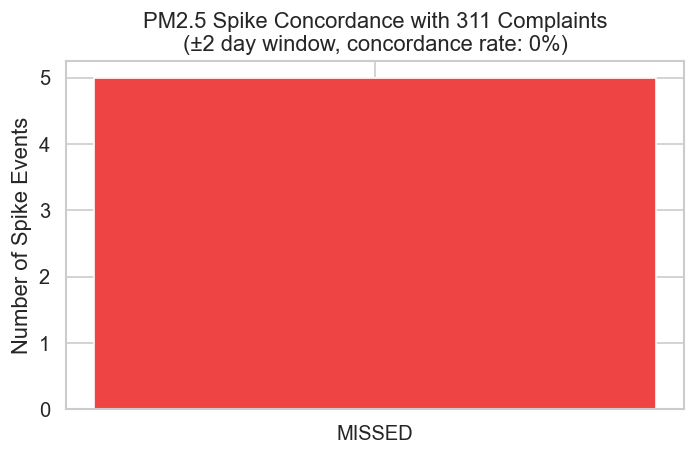

In [10]:
# ── 6a. Spike Concordance ─────────────────────────────────────────────────────
spike_days = merged[merged["pm25_spike"] == 1].copy()
print(f"Total PM2.5 spike sensor-days (>35 µg/m³): {len(spike_days)}")

if len(spike_days) > 0:
    # For each spike day, check complaints within ±2 days at same sensor
    merged_sorted = merged.sort_values(["sensor_name", "date"])

    concordance = []
    for _, spike in spike_days.iterrows():
        sensor = spike["sensor_name"]
        spike_date = spike["date"]
        window = merged[
            (merged["sensor_name"] == sensor)
            & (merged["date"] >= spike_date - pd.Timedelta(days=2))
            & (merged["date"] <= spike_date + pd.Timedelta(days=2))
        ]
        total_complaints = window["complaint_count"].sum()
        concordance.append({
            "sensor_name": sensor,
            "spike_date": spike_date,
            "pm25": spike["pm25_mean"],
            "complaints_in_window": total_complaints,
            "concordance": "CONCORDANT" if total_complaints > 0 else "MISSED",
        })

    conc_df = pd.DataFrame(concordance)
    conc_rate = (conc_df["concordance"] == "CONCORDANT").mean()

    print(f"\nConcordance rate: {conc_rate:.1%}")
    print(f"  CONCORDANT (spike + complaint): {(conc_df['concordance'] == 'CONCORDANT').sum()}")
    print(f"  MISSED (spike, no complaint):   {(conc_df['concordance'] == 'MISSED').sum()}")

    # Also check false alarms: complaints on non-spike days
    non_spike = merged[merged["pm25_spike"] == 0]
    false_alarm_days = non_spike[non_spike["complaint_count"] > 0]
    print(f"\n  FALSE ALARMS (complaint, no spike): {len(false_alarm_days)} sensor-days")

    # Visualize
    if len(conc_df) > 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        counts = conc_df["concordance"].value_counts()
        colors = {"CONCORDANT": "#22c55e", "MISSED": "#ef4444"}
        ax.bar(counts.index, counts.values,
               color=[colors.get(x, "#94a3b8") for x in counts.index],
               edgecolor="white")
        ax.set_ylabel("Number of Spike Events")
        ax.set_title(f"PM2.5 Spike Concordance with 311 Complaints\n(±2 day window, concordance rate: {conc_rate:.0%})")
        plt.tight_layout()
        plt.show()
else:
    print("No PM2.5 spike days found in dataset. Try lowering the threshold.")

## Section 7 — SQL Validation

Quick validation: run one of our portfolio SQL queries against the SQLite database to demonstrate the SQL → Python workflow.

In [ ]:
# ── 7a. Run SQL: Neighborhood Ranking from SQLite ────────────────────────────
conn = sqlite3.connect(DB_PATH)

query = """
SELECT
    d.sensor_name,
    ROUND(AVG(d.pm25_mean), 1)               AS avg_pm25,
    SUM(d.complaint_count)                    AS total_complaints,
    COUNT(*)                                  AS total_days,
    ROUND(1.0 * SUM(d.complaint_count)
          / COUNT(*), 4)                      AS complaints_per_day,
    ROUND(AVG(d.lat), 4)                      AS lat,
    ROUND(AVG(d.lon), 4)                      AS lon,
    d.neighborhood AS naynay
FROM daily_merged d
GROUP BY d.sensor_name
HAVING total_complaints > 0
ORDER BY complaints_per_day DESC
LIMIT 100;
"""

try:
    ranking = pd.read_sql_query(query, conn)
    print("═══ Top 15 Sensor Areas by Complaint Rate ═══\n")
    display(ranking)
except Exception as e:
    print(f"SQL query failed (is the database loaded?): {e}")
finally:
    conn.close()

SQL query failed (is the database loaded?): Execution failed on sql '
SELECT
    d.sensor_name,
    ROUND(AVG(d.pm25_mean), 1)               AS avg_pm25,
    SUM(d.complaint_count)                    AS total_complaints,
    COUNT(*)                                  AS total_days,
    ROUND(1.0 * SUM(d.complaint_count)
          / COUNT(*), 4)                      AS complaints_per_day,
    ROUND(AVG(d.lat), 4)                      AS lat,
    ROUND(AVG(d.lon), 4)                      AS lon
    d.neighborhood
FROM daily_merged d
GROUP BY d.sensor_name
HAVING total_complaints > 0
ORDER BY complaints_per_day DESC
LIMIT 100;
': near "d": syntax error


---

## Next Steps → Tableau

The cleaned & merged CSV (`data/clean/merged_complaints_air.csv`) and SQLite database (`db/citizen_sensor.db`) are ready for Tableau:

1. **Connect** Tableau to `merged_complaints_air.csv` (or use the SQLite ODBC connector)
2. **Map view:** Dual-layer — sensor locations (color = avg PM2.5) + complaint hotspots
3. **Dual-axis time series:** PM2.5 (left axis) + complaint count (right axis), filterable by sensor
4. **Spike concordance highlight table:** Days with spikes colored by concordance status
5. **Lead/lag bar chart:** Average complaints at each lag day relative to PM2.5 spikes

Publish to Tableau Public with filter actions linking map clicks to the time series.